## Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance
from datasets import Dataset


## Raw Data XGBoost

In [2]:
# ==========================================
# DATA LOADING & PREPROCESSING
# ==========================================
print("Loading freMTPL2freq dataset...")
dataset = fetch_openml(data_id=41214, as_frame=True)
dat = dataset.frame

# Clean basic types first
dat['ClaimNb'] = pd.to_numeric(dat['ClaimNb'])
dat['Exposure'] = pd.to_numeric(dat['Exposure'])
dat['Exposure'] = dat['Exposure'].clip(upper=1.0)
dat['Frequency'] = dat['ClaimNb'] / dat['Exposure']

dat = pd.get_dummies(dat, columns=['VehGas'],drop_first=True)
dat = pd.get_dummies(dat, columns=['VehBrand'],drop_first=True)
dat = pd.get_dummies(dat, columns=['Region'],drop_first=True)
area_remapping = {
    "A": 1,
    "B": 2,
    "C": 3,
    "D": 4,
    "E": 5,
    "F": 6
}
dat["Area"] = dat["Area"].map(area_remapping)

dat['VehPowerGLM'] = pd.Categorical(np.minimum(dat['VehPower'], 9))

dat['VehAgeGLM'] = pd.cut(
    dat['VehAge'],
    bins=[0, 5, 12, 101],
    labels=["0-5", "6-12", "12+"],
    include_lowest=True
)

dat['DrivAgeGLM'] = pd.cut(
    dat['DrivAge'],
    bins=[18, 20, 25, 30, 40, 50, 70, 101],
    labels=["18-20", "21-25", "26-30", "31-40", "41-50", "51-70", "71+"],
    include_lowest=True
)

dat['BonusMalusGLM'] = np.minimum(dat['BonusMalus'], 150)

dat['DensityGLM'] = np.log(dat["Density"].astype(float))

dat = pd.get_dummies(dat, columns=['DrivAgeGLM'],drop_first=True)
dat = pd.get_dummies(dat, columns=['VehAgeGLM'],drop_first=True)
dat = pd.get_dummies(dat, columns=['VehPowerGLM'],drop_first=True)

dat = dat.drop(["VehPower", "VehAge", "DrivAge", "BonusMalus","Density"], axis = 1)
dat = dat.astype('float32')


Loading freMTPL2freq dataset...


In [3]:
import pandas as pd
from sklearn.datasets import fetch_openml

# Load the split indices
df_splits = pd.read_csv('freMTPL2freq_split_indices.csv')

# Ensure IDpol is the same type in both dataframes for a clean merge
dat['IDpol'] = dat['IDpol'].astype(int)
df_splits['IDpol'] = df_splits['IDpol'].astype(int)

# Merge the dataset with the split indicators
# We use a left join to keep the original data rows
df_merged = dat.merge(df_splits, on='IDpol', how='left')

# Create the subsets based on the indicator columns
train_df = df_merged[df_merged['is_train'] == 1].drop(columns=['is_train', 'is_test', 'is_finetune']).copy()
test_df = df_merged[df_merged['is_test'] == 1].drop(columns=['is_train', 'is_test', 'is_finetune']).copy()
finetune_df = df_merged[df_merged['is_finetune'] == 1].drop(columns=['is_train', 'is_test', 'is_finetune']).copy()

# Print results
print(f"Total rows: {len(dat)}")
print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")
print(f"Finetune rows: {len(finetune_df)}")

# Inspecting the training set
print(train_df.head())

Total rows: 678013
Train rows: 500000
Test rows: 100000
Finetune rows: 76782
   IDpol  ClaimNb  Exposure  Area  Frequency  VehGas_'Regular'  VehBrand_B10  \
1      3      1.0      0.77   4.0   1.298701               1.0           0.0   
3     10      1.0      0.09   2.0  11.111111               0.0           0.0   
4     11      1.0      0.84   2.0   1.190476               0.0           0.0   
5     13      1.0      0.52   5.0   1.923077               1.0           0.0   
7     17      1.0      0.27   3.0   3.703704               0.0           0.0   

   VehBrand_B11  VehBrand_B12  VehBrand_B13  ...  DrivAgeGLM_41-50  \
1           0.0           1.0           0.0  ...               0.0   
3           0.0           1.0           0.0  ...               1.0   
4           0.0           1.0           0.0  ...               1.0   
5           0.0           1.0           0.0  ...               0.0   
7           0.0           1.0           0.0  ...               0.0   

   DrivAgeGLM_51-70  

In [4]:
train_df = train_df.drop(["Frequency", "IDpol"], axis = 1).astype('float32')
test_df = test_df.drop(["Frequency", "IDpol"], axis = 1).astype('float32')

In [5]:
# Separate Predictors from Meta Data
meta_cols = ['ClaimNb', 'Exposure']
pred_cols = train_df.columns.difference(meta_cols)

X_train = train_df[pred_cols]
meta_train = train_df[meta_cols]

X_test = test_df[pred_cols]
meta_test = test_df[meta_cols]

# Concatenate
final_train = pd.concat([X_train, meta_train], axis=1)
final_test = pd.concat([X_test, meta_test], axis=1)

print(final_train.head())

   Area  BonusMalusGLM  DensityGLM  DrivAgeGLM_21-25  DrivAgeGLM_26-30  \
1   4.0           50.0    7.104144               0.0               0.0   
3   2.0           50.0    4.330733               0.0               0.0   
4   2.0           50.0    4.330733               0.0               0.0   
5   5.0           50.0    8.007367               0.0               0.0   
7   3.0           68.0    4.919981               0.0               0.0   

   DrivAgeGLM_31-40  DrivAgeGLM_41-50  DrivAgeGLM_51-70  DrivAgeGLM_71+  \
1               0.0               0.0               1.0             0.0   
3               0.0               1.0               0.0             0.0   
4               0.0               1.0               0.0             0.0   
5               1.0               0.0               0.0             0.0   
7               1.0               0.0               0.0             0.0   

   Region_R21  ...  VehBrand_B5  VehBrand_B6  VehGas_'Regular'  VehPowerGLM_5  \
1         0.0  ...     

In [8]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_poisson_deviance

# Identify predictors (excluding ClaimNb and Exposure)
predictors = [c for c in final_train.columns if c not in ['ClaimNb', 'Exposure']]

# Prepare DMatrix with Offset (base_margin)
# XGBoost's Poisson objective requires log-exposure as the base_margin
dtrain = xgb.DMatrix(final_train[predictors], label=final_train['ClaimNb'])
dtrain.set_base_margin(np.log(final_train['Exposure']))

dtest = xgb.DMatrix(final_test[predictors], label=final_test['ClaimNb'])
dtest.set_base_margin(np.log(final_test['Exposure']))

# Define Parameters
xgb_params = {
    'objective': 'count:poisson',
    'eval_metric': 'poisson-nloglik',
    'learning_rate': 0.1,
    'max_depth': 6,
    'tree_method': 'hist'
}

# Train Model
bst = xgb.train(
    xgb_params, 
    dtrain, 
    num_boost_round=150,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    early_stopping_rounds=10,
    verbose_eval=25
)

# Predict & Evaluate
# .predict() automatically incorporates the base_margin to return counts
preds = bst.predict(dtest)
mpd = mean_poisson_deviance(final_test['ClaimNb'], preds)
print(f"\nXGBoost Test Mean Poisson Deviance: {mpd:.6f}")

[0]	train-poisson-nloglik:0.54727	test-poisson-nloglik:0.54786
[25]	train-poisson-nloglik:0.27634	test-poisson-nloglik:0.27787
[50]	train-poisson-nloglik:0.21783	test-poisson-nloglik:0.22049
[75]	train-poisson-nloglik:0.20787	test-poisson-nloglik:0.21143
[100]	train-poisson-nloglik:0.20600	test-poisson-nloglik:0.21021
[125]	train-poisson-nloglik:0.20530	test-poisson-nloglik:0.21000
[149]	train-poisson-nloglik:0.20477	test-poisson-nloglik:0.20982

XGBoost Test Mean Poisson Deviance: 0.315141


Size 1000: Test MPD = 0.37448
Size 5000: Test MPD = 0.33449
Size 10000: Test MPD = 0.32993
Size 50000: Test MPD = 0.31908
Size 100000: Test MPD = 0.31769
Size 500000: Test MPD = 0.31595


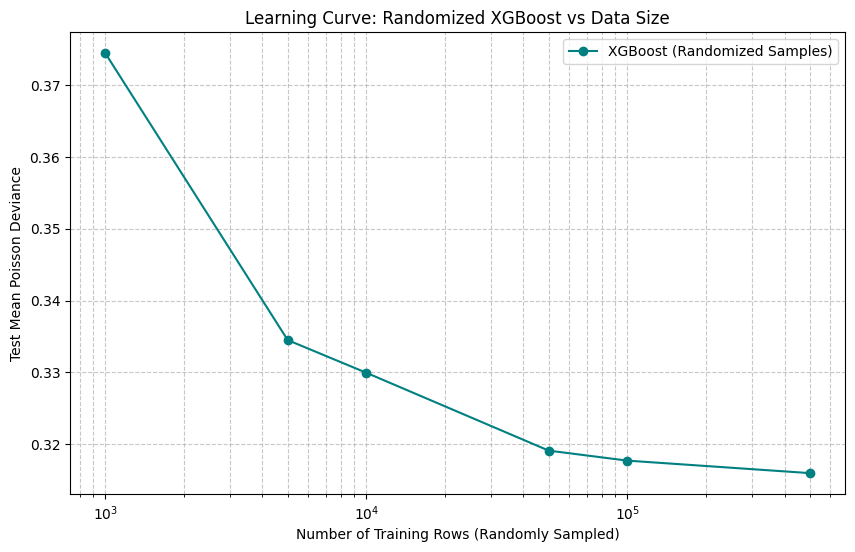

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_poisson_deviance
import statsmodels.api as sm

# Randomize the training data at the start
# frac=1 shuffles 100% of the data; reset_index ensures iloc works as expected
train_df_shuffled = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

meta_cols = ['ClaimNb', 'Exposure']
pred_cols = train_df_shuffled.columns.difference(meta_cols)

# Prepare Matrices from the shuffled set
X_train_raw = train_df_shuffled[pred_cols]
y_train = train_df_shuffled['ClaimNb']
offset_train = train_df_shuffled['Exposure'] 

# Test set remains fixed (no shuffling needed for evaluation set)
X_test_raw = test_df[pred_cols]
y_test = test_df['ClaimNb']
offset_test = test_df['Exposure']

# Configuration
# Use min() to prevent errors if the dataset is smaller than 500k
max_available = len(train_df_shuffled)
train_sizes = [s for s in [1000, 5000, 10000, 50000, 100000, 500000] if s <= max_available]
deviances_xgb = []

xgb_params = {
    'objective': 'count:poisson',
    'learning_rate': 0.1,
    'max_depth': 6,
    'tree_method': 'hist',
    'nthread': -1
}

# Fixed Test Set for Consistency
dtest = xgb.DMatrix(X_test_raw, label=y_test)
dtest.set_base_margin(np.log(offset_test))

# Learning Curve Loop
for size in train_sizes:
    # Slice the subset (now a random subset due to the initial shuffle)
    X_sub = X_train_raw.iloc[:size]
    y_sub = y_train.iloc[:size]
    off_sub = offset_train.iloc[:size]
    
    # Prepare Training DMatrix
    dtrain = xgb.DMatrix(X_sub, label=y_sub)
    dtrain.set_base_margin(np.log(off_sub))
    
    # Train
    bst = xgb.train(xgb_params, dtrain, num_boost_round=100)
    
    # Predict and Score
    preds = bst.predict(dtest)
    mpd = mean_poisson_deviance(y_test, preds)
    deviances_xgb.append(mpd)
    
    print(f"Size {size}: Test MPD = {mpd:.5f}")

# Plotting 
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, deviances_xgb, marker='o', linestyle='-', color='teal', label='XGBoost (Randomized Samples)')

plt.xscale('log')
plt.title('Learning Curve: Randomized XGBoost vs Data Size')
plt.xlabel('Number of Training Rows (Randomly Sampled)')
plt.ylabel('Test Mean Poisson Deviance')
plt.grid(True, linestyle='--', alpha=0.7, which='both')
plt.legend()
plt.show()